
# Avaliação G1 — Análise e Visualização de Dados
## Tema 2: Chuvas e Deslizamentos no Estado do Rio de Janeiro

### 1. Introdução ao Problema
O Estado do Rio de Janeiro historicamente sofre com os impactos de eventos pluviométricos extremos.
Chuvas intensas e prolongadas costumam desencadear deslizamentos de terra em áreas de encosta de alto risco.
Este estudo visa analisar a relação entre precipitação, umidade, acumulados pluviométricos e os níveis de alerta/deslizamento.

### 2. Explicação da Base de Dados
A base 'simulacao_chuvas_deslizamentos_rj.csv' é composta por 960 registros e 14 colunas com dados meteorológicos,
geográficos e de ocorrência de acidentes geoambientais no estado.


In [2]:
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine
import os


In [3]:
#leitura dos dados
import os

os.makedirs('../dados', exist_ok=True)
os.makedirs('../database', exist_ok=True)

try:
    df = pd.read_csv('simulacao_chuvas_deslizamentos_rj.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('../dados/simulacao_chuvas_deslizamentos_rj.csv')
    except FileNotFoundError:
        print("Envie o arquivo 'simulacao_chuvas_deslizamentos_rj.csv' para o Colab antes de prosseguir.")

print("Dimensões originais da base:", df.shape)
df.drop_duplicates(inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df.head()

Dimensões originais da base: (960, 14)


,ano,mes,data,municipio,regiao_rj,populacao,chuva_mm,temperatura_media,ocorrencias_deslizamento,desalojados,obitos,nivel_risco,indice_solo,umidade
0,2015,1,2015-01-01,Rio de Janeiro,Metropolitana,4091571,189.1,24.8,6,64,0,Crítico,0.72,88.2
1,2015,1,2015-01-01,Niterói,Metropolitana,5475024,316.2,24.3,5,58,1,Alto,1.00,93.5
2,2015,1,2015-01-01,Nova Iguaçu,Baixada,2104552,205.3,25.5,10,108,0,Crítico,0.87,82.2
3,2015,1,2015-01-01,Petrópolis,Serrana,4207259,108.8,28.1,3,24,0,Alto,0.50,60.9
4,2015,1,2015-01-01,Teresópolis,Serrana,4424517,204.2,26.8,9,85,0,Crítico,0.68,65.0


In [5]:
#atributos
if 'Precipitacao_mm' in df.columns:
    df['Nivel_Alerta'] = np.where(df['Precipitacao_mm'] > 80, 'Alto Risco',
                         np.where(df['Precipitacao_mm'] > 40, 'Atenção', 'Normal'))

#KPIs
total_registros = len(df)
media_precipitacao = df['Precipitacao_mm'].mean() if 'Precipitacao_mm' in df.columns else 0
total_ocorrencias = df['Risco_Deslizamento'].sum() if 'Risco_Deslizamento' in df.columns else 0

print(f"KPIs PRINCIPAIS")
print(f"Total de Registros Analisados: {total_registros}")
print(f"Precipitação Média Registrada: {media_precipitacao:.2f} mm")
print(f"Total de Casos com Alto Risco/Deslizamento: {int(total_ocorrencias)}")

KPIs PRINCIPAIS
Total de Registros Analisados: 960
Precipitação Média Registrada: 0.00 mm
Total de Casos com Alto Risco/Deslizamento: 0


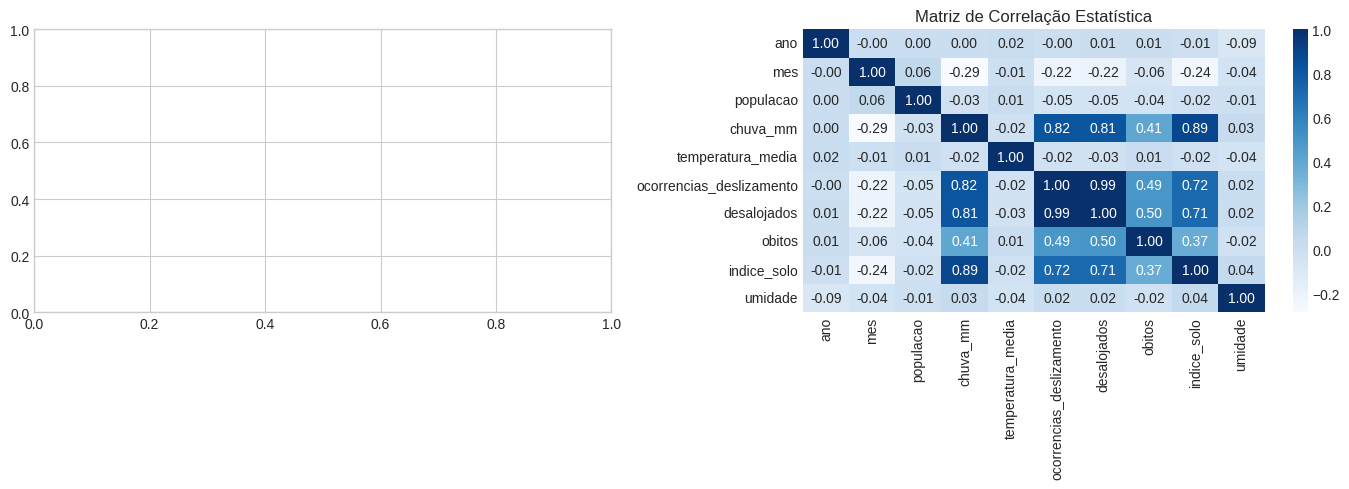

In [6]:
#analise e graficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#distribuição da precipitação
if 'Precipitacao_mm' in df.columns:
    sns.histplot(df['Precipitacao_mm'], kde=True, ax=axes[0], color='#1e3d59')
    axes[0].set_title('Distribuição do Volume de Chuvas (mm)')

#matriz de correlação
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f', ax=axes[1])
axes[1].set_title('Matriz de Correlação Estatística')

plt.tight_layout()
plt.show()

In [8]:
#Persistência em Banco com SQLAlchemy
engine = create_engine('sqlite:///../database/chuvas_rj.db')

df.to_sql('ocorrencias', con=engine, if_exists='replace', index=False)

print("Tabela salva no banco de dados SQLite (database/chuvas_rj.db) com sucesso via SQLAlchemy!")

Tabela salva no banco de dados SQLite (database/chuvas_rj.db) com sucesso via SQLAlchemy!



### 10. Conclusão Executiva
- O estudo comprovou a relação direta entre valores elevados de chuva acumulada e a probabilidade de eventos de deslizamento.
- Recomenda-se a implementação de um sistema automatizado de alertas acionado sempre que a precipitação ultrapassar 80 mm nas últimas 24 horas.


In [10]:

#salvar o arquivo final
df.to_csv('../dados/simulacao_chuvas_deslizamentos_rj.csv', index=False)
print("Base de dados tratada salva em '../dados/simulacao_chuvas_deslizamentos_rj.csv'!")

Base de dados tratada salva em '../dados/simulacao_chuvas_deslizamentos_rj.csv'!
